In [36]:
import pandas as pd
import matplotlib.pyplot as plt



In [96]:
path = "/Users/albertolsen/Documents/Stud.Polit./11. Bologna/Development Economics/data.xlsx"
sheet = "Harmonized data set"
# Load an Excel file into a DataFrame
df = pd.read_excel(path, sheet, skiprows=[0])
print(df.head())

    RESPNO  URBRUR  EA_SVC_A  EA_SVC_B  EA_SVC_C  EA_FAC_A  EA_FAC_B  \
0  SEN0001       2         0         0         0         0         1   
1  SEN0002       2         0         0         0         0         1   
2  SEN0003       2         0         0         0         0         1   
3  SEN0004       2         0         0         0         0         1   
4  SEN0005       2         0         0         0         0         1   

   EA_FAC_C  EA_FAC_D  EA_FAC_E  ...  Q108  Q110A  Q110B  Q110C Q110D Q110E  \
0         0         0         0  ...    -1      1      1      1     1     1   
1         0         0         0  ...     0      1      1      1     1     1   
2         0         0         0  ...     0      1      1      1     1     1   
3         0         0         0  ...     0      1      1      1     1     1   
4         0         0         0  ...     1      1      1      1     1     1   

   Q110F  Q116  Q118   Round   
0      1   365     7  Round 3  
1      1   365     7  Round 

This shows some of the basic commands for descriptive statistics


In [ ]:
df.mean()
df.median()

min(df)
max(df["column_name"])

df["column_name"].quantile(0)
df["column_name"].quantile(0.25)

df["column_name"].describe() # gives min, max and quartiles and std
df["column_name"].std()
df["column_name"].var()

# skewness and kurtosis
df["column_name"].skew()    # measures whether the mass of the data is concentrated on the left or right of the mean
df["column_name"].kurtosis() # or .kurt() measures how heavy the tails of the distribution are compared to a normal distribution


This shows code for the basic figures you can make in descriptive statistics 
Histogram
Boxplot \\
Scatterplot, scatterplot with a trend line \\
Basic diagrams \\
- Line, columns, circles

In [ ]:
# Boxplot

df.boxplot(column="column_name",
               by="grouping_column",
               return_type="axes",
               figsize=(h, w), 
               grid=False)


In [ ]:
# Histogram
df.hist(column="column_name", bins=10, figsize=(h, w), grid=False)

In [16]:
print(df.columns)

Index(['RESPNO', 'URBRUR', 'EA_SVC_A', 'EA_SVC_B', 'EA_SVC_C', 'EA_FAC_A',
       'EA_FAC_B', 'EA_FAC_C', 'EA_FAC_D', 'EA_FAC_E',
       ...
       'Q108', 'Q110A', 'Q110B', 'Q110C', 'Q110D', 'Q110E', 'Q110F', 'Q116',
       'Q118', 'Round '],
      dtype='object', length=101)


Here begins the analysis. We want to look at: 1. Trust in the different institutions. 2. over all trust. 3. How this differs between those who feel Senegalese and those who don't. 

In [216]:
# The question that expresses feeling of identity is "Q85B"

# We find the questions that express trust in institutions. 
trust = df[["Q43A", "Q43B", "Q43E", "Q43F", "Q43I"]]

# I remove -1 and 9, 'missing' and 'don't know'
trust = trust[~trust.isin([-1]).any(axis=1)]
trust = trust[~trust.isin([9]).any(axis=1)]

# now we have 4998 values
print(trust.count())

# Create a new DataFrame to hold the percentage shares
trust_share = trust.apply(lambda x: x.value_counts(normalize=True).fillna(0) )

# Display the new DataFrame
print(trust_share)



Q43A    4998
Q43B    4998
Q43E    4998
Q43F    4998
Q43I    4998
dtype: int64
       Q43A      Q43B      Q43E      Q43F      Q43I
0  0.170268  0.254302  0.288115  0.314726  0.118247
1  0.158463  0.215286  0.215286  0.256503  0.145658
2  0.201281  0.224090  0.225690  0.238495  0.249900
3  0.469988  0.306323  0.270908  0.190276  0.486194


In [217]:
# Labels
# BEGIN: Custom labels
trust_labels = {1: 'Not at all', 2: 'A little', 3: 'Somehow', 4: 'A lot'}  # Define your custom labels



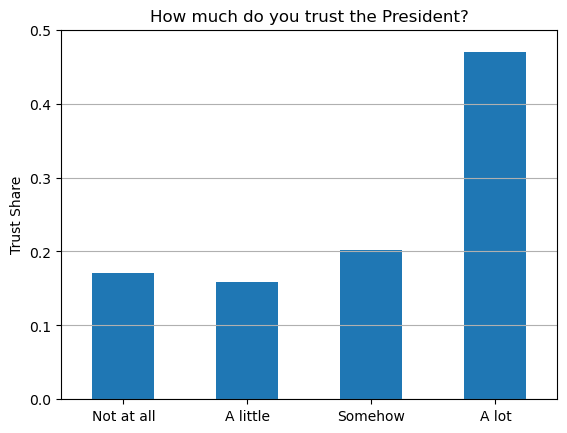

In [218]:
# Bar chart for trust in the president. 
# So now we can easily replicate this for all the variables. 

trust_share["Q43A"].plot(kind= "bar", stacked=True)
plt.grid(axis='y')
plt.ylim(0,0.5)
plt.xticks(ticks=range(len(trust_labels)), labels=trust_labels.values(), rotation=0)
plt.ylabel('Trust Share')
plt.title("How much do you trust the President?")
plt.show()

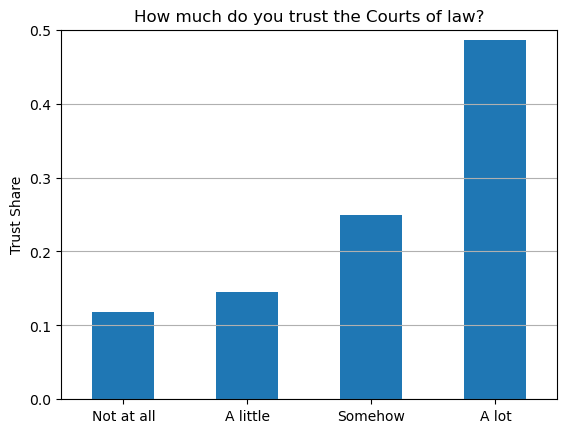

In [219]:
# How much do you trust the courts?

trust_share["Q43I"].plot(kind= "bar", stacked=True)
plt.grid(axis='y')
plt.ylim(0,0.5)
plt.xticks(ticks=range(len(trust_labels)), labels=trust_labels.values(), rotation=0)
plt.ylabel('Trust Share')
plt.title("How much do you trust the Courts of law?")
plt.show()

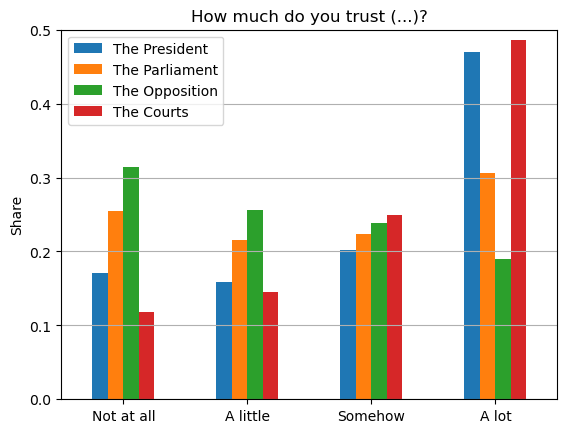

In [220]:
ax = trust_share[["Q43A","Q43B","Q43F","Q43I"]].plot(kind="bar")

ax.legend(["The President", "The Parliament", "The Opposition","The Courts"])

plt.grid(axis='y')
plt.ylim(0, 0.5)
plt.xticks(ticks=range(len(trust_labels)), labels=trust_labels.values(), rotation=0)
plt.ylabel('Share')
plt.title("How much do you trust (...)?")
plt.show()

Now we try to look at trust throughout the years. Individually for trusting the different things. 

Q43A      5795
Round     5795
dtype: int64
Q43A            0         1         2         3
Round                                          
Round 3  0.116341  0.101243  0.151865  0.630551
Round 4  0.353819  0.154522  0.173837  0.317823
Round 5  0.107784  0.167665  0.230967  0.493584
Round 6  0.159187  0.182896  0.219306  0.438611
Round 7  0.096610  0.163559  0.201695  0.538136


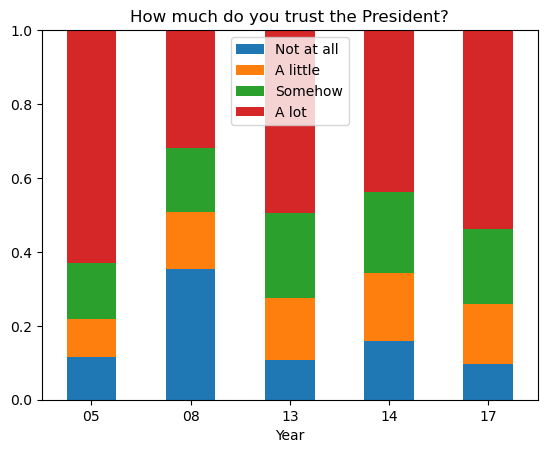

In [230]:
trust_pres = df[["Q43A","Round "]]

trust_pres = trust_pres[~trust_pres.isin([-1]).any(axis=1)]
trust_pres = trust_pres[~trust_pres.isin([9]).any(axis=1)]

print(trust_pres.count())

pres_share = trust_pres["Q43A"].value_counts(normalize=True)
pres_share_round = trust_pres.groupby('Round ')['Q43A'].value_counts(normalize=True).unstack(fill_value=0)

print(pres_share_round)

# creating the label
round_labels = {1: "05", 2: '08', 3: '13', 4: '14', 5: '17'}  # Define your custom labels


pres_round = pres_share_round.plot(kind='bar', stacked=True)
pres_round.legend(['Not at all', 'A little', 'Somehow', 'A lot'])
plt.title("How much do you trust the President?")
plt.xticks(ticks = range(len(round_labels)), labels = round_labels.values(), rotation=0, ha='center')
plt.xlabel('Year')
plt.ylim(0, 1)
plt.show()


Q43B      5469
Round     5469
dtype: int64
Q43B            0         1         2         3         8
Round                                                    
Round 3  0.201389  0.130952  0.207341  0.460317  0.000000
Round 4  0.413346  0.176089  0.172382  0.238184  0.000000
Round 5  0.158688  0.253546  0.243794  0.343972  0.000000
Round 6  0.265378  0.224956  0.241652  0.268014  0.000000
Round 7  0.230287  0.276882  0.252688  0.239247  0.000896


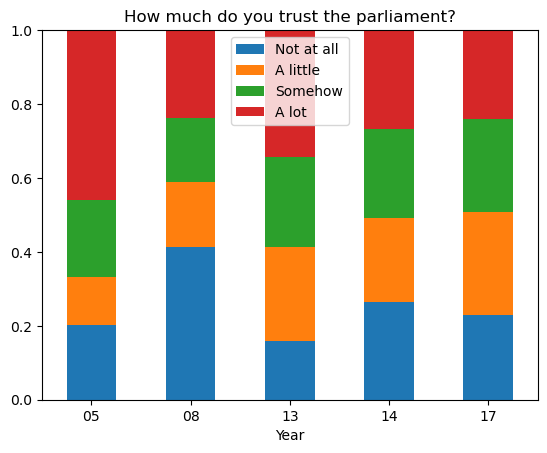

In [237]:
# How much do you trust the parliament?

trust_parl = df[["Q43B","Round "]]

trust_parl = trust_parl[~trust_parl.isin([-1]).any(axis=1)]
trust_parl = trust_parl[~trust_parl.isin([9]).any(axis=1)]

print(trust_parl.count())

parl_share = trust_parl["Q43B"].value_counts(normalize=True)
parl_share_round = trust_parl.groupby('Round ')['Q43B'].value_counts(normalize=True).unstack(fill_value=0)

print(parl_share_round)

# creating the label
round_labels = {1: "05", 2: '08', 3: '13', 4: '14', 5: '17'}  # Define your custom labels


parl_round = parl_share_round.plot(kind='bar', stacked=True)
parl_round.legend(['Not at all', 'A little', 'Somehow', 'A lot'])
plt.title("How much do you trust the parliament?")
plt.xticks(ticks = range(len(round_labels)), labels = round_labels.values(), rotation=0, ha='center')
plt.xlabel('Year')
plt.ylim(0, 1)
plt.show()


Q43I      5552
Round     5552
dtype: int64
Q43I            0         1         2         3
Round                                          
Round 3  0.099344  0.087160  0.156514  0.656982
Round 4  0.134477  0.107401  0.242780  0.515343
Round 5  0.099291  0.125887  0.238475  0.536348
Round 6  0.130435  0.184561  0.310559  0.374445
Round 7  0.111408  0.203209  0.272727  0.412656


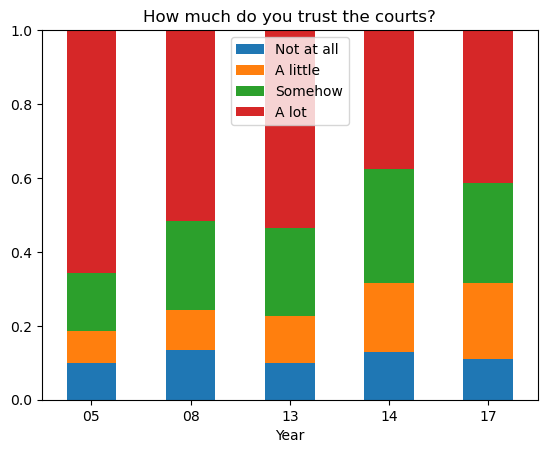

In [236]:
# How much do you trust the courts?

trust_courts = df[["Q43I","Round "]]

trust_courts = trust_courts[~trust_courts.isin([-1]).any(axis=1)]
trust_courts = trust_courts[~trust_courts.isin([9]).any(axis=1)]

print(trust_courts.count())

courts_share = trust_courts["Q43I"].value_counts(normalize=True)
courts_share_round = trust_courts.groupby('Round ')['Q43I'].value_counts(normalize=True).unstack(fill_value=0)

print(courts_share_round)

# creating the label
round_labels = {1: "05", 2: '08', 3: '13', 4: '14', 5: '17'}  # Define your custom labels


courts_round = courts_share_round.plot(kind='bar', stacked=True)
courts_round.legend(['Not at all', 'A little', 'Somehow', 'A lot'])
plt.title("How much do you trust the courts?")
plt.xticks(ticks = range(len(round_labels)), labels = round_labels.values(), rotation=0, ha='center')
plt.xlabel('Year')
plt.ylim(0, 1)
plt.show()


From here we look at how much people feel Senegalese

In [221]:
# Do you feel Senegalese?
# The question that expresses feeling of identity is "Q85B"

ethnic_labels = {1: "Only ethnic", 2: "most ethnic", 3: "Equally", 4: "Most Senegalese", 5: "Only Senegalese"}

# I remove the variables that are not relevant. 

identity = df[["Q85B","Round "]]
print(identity["Q85B"].value_counts())

identity = identity[~identity.isin([-1]).any(axis=1)]
identity = identity[~identity.isin([7]).any(axis=1)]
identity = identity[~identity.isin([9]).any(axis=1)]

print(identity.head())
print(identity.count())


Q85B
 5    2673
 3    2114
 2     492
 4     372
 1     261
 9      52
 7      22
-1      14
Name: count, dtype: int64
   Q85B   Round 
0     3  Round 3
1     5  Round 3
2     5  Round 3
3     5  Round 3
4     1  Round 3
Q85B      5912
Round     5912
dtype: int64


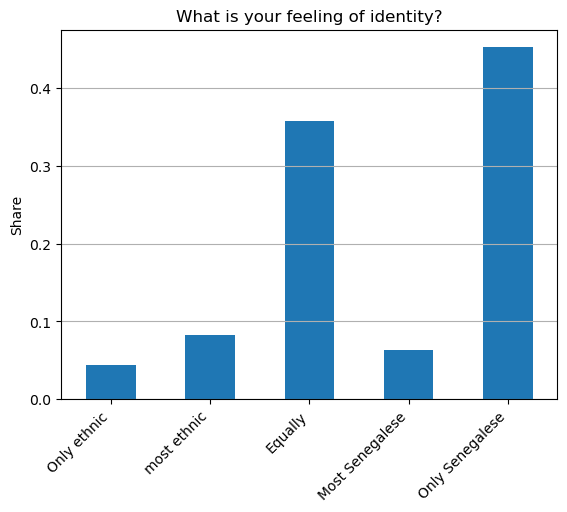

In [193]:
ident_share = identity["Q85B"].value_counts(normalize=True)

ident_share = (
    identity["Q85B"]
    .value_counts(normalize=True)
    .sort_index()
    .reindex([1,2,3,4,5], fill_value=0)
)

ident_share.plot(kind= "bar", stacked = True)
plt.grid(axis='y')
plt.xticks(ticks=range(len(ethnic_labels)), labels=ethnic_labels.values(), rotation=45, ha='right')
plt.ylabel('Share')
plt.xlabel("")
plt.title("What is your feeling of identity?")
plt.show()


# Adjusting xticks to avoid overlap using vertical alignment


Q85B            1         2         3         4         5
Round                                                    
Round 3  0.035133  0.075407  0.380463  0.078835  0.430163
Round 4  0.043111  0.124260  0.257819  0.092139  0.482671
Round 5  0.050127  0.084112  0.324554  0.065421  0.475786
Round 6  0.031960  0.051304  0.390244  0.031960  0.494533
Round 7  0.060201  0.081104  0.433946  0.046823  0.377926


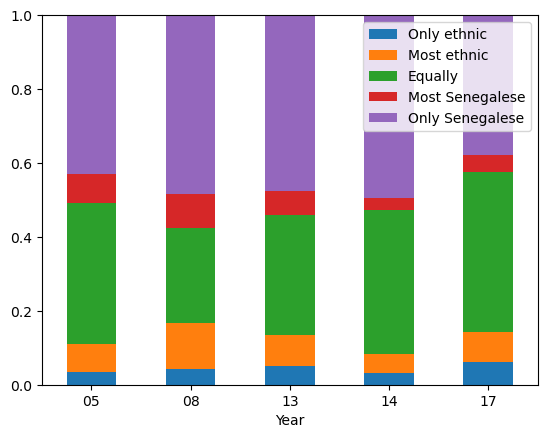

In [194]:
# Calculate the share for each round
ident_share_by_round = identity.groupby('Round ')['Q85B'].value_counts(normalize=True).unstack(fill_value=0)
print(ident_share_by_round)

# creating the label
round_labels = {1: "05", 2: '08', 3: '13', 4: '14', 5: '17'}  # Define your custom labels



ident_round = ident_share_by_round.plot(kind='bar', stacked=True)
ident_round.legend(['Only ethnic', 'Most ethnic', 'Equally', 'Most Senegalese', 'Only Senegalese'])
plt.xticks(ticks = range(len(round_labels)), labels = round_labels.values(), rotation=0, ha='center')
plt.xlabel('Year')
plt.ylim(0, 1)
plt.show()

#plt.xticks(ticks = range(len(trust_labels)), labels=trust_labels.values(), rotation=0)

